# Problem Definition
Diabetes is a chronic medical condition that effects millions of people worldwide. Early detection of diabetes is essential to prevent severe complications such as heart disease, kidney failure, and vision loss.

Our project aims to develop a machine learning-based classification model that predicts whether an individual has diabetes using clinical and demographic health features. By analyzing patient data, the model assists in identifying high-risk individuals and supports early screening efforts.

Objectives


*   To analyze a medical dataset related to diabetes.
*   To preprocess and prepare the data for machine learning.
*   To develop a Random Forest model to classify individuals as diabetic or non-diabetic.
*   To evaluate the model using appropriate performance metrics such as recall, precision, confusion matrix, and ROC curve.
*   To interpret the model results for potential healthcare applications.

Why Machine Learning?

Diabetes diagnosis involve multiple interacting factors such as age, body mass index, glucose levels, and blood pressure. Machine learning techniques are well-suited to identify complex relationships among these features and provide accurate predictions. Random Forest was selected for its high accuracy, ability to handle complex nonlinear relationships, robustness to overfitting, and suitability for both classification and regression tasks in medical applications.


Scope of our project

This project focuses on predicting diabetes based on strctured clinical data. The model is intended as a decision-support tool and does not replace professional medical diagnosis. The study limited to the selected dataset and does not include real-time patient monitoring or treatment recommendations.


# Data Description and Understanding

Dataset Source

The dataset used in this project is the PIMA Indians Diabetes Dataset, which is publicly available and widely used for research purposes. The dataset contains medical diagnostic measurements for female patients of Pima Indian heritage and is commonly employed in machine learning studies related to diabetes prediction.

Full Citation

* Smith, J. W., Everhart, J. E., Dickson, W. C., Knowler, W. C., &
Johannes, R. S. (1988).
Using the ADAP learning algorithm to forecast the onset of diabetes mellitus.
Proceedings of the Symposium on Computer Applications and Medical Care, 261–265.

* UCI Machine Learning Repository. Pima Indians Diabetes Dataset.

The dataset consists of 768 patient records, each containing eight clinical features along with a binary outcome variable indicating the presence or absence of diabetes. The data is structured and suitable for supervised machine learning classification tasks.

Feature Description

The dataset includes clinical attributes such as glucose concentration, blood pressure, insulin level, and body mass index, which are known as factors for diabetes. Also thereare factors like pregancies, skin thickness, DiabetesPedigreeFunction, and age. The target variable, labeled as "Outcome", indicates whether the patient has diabetes(1) or does not have diabetes(0).

Dataset Suitability

This dataset is suitable for the proposed problem because it contains relevant clinical features associated with diabetes and provides labeled outcomes required for supervised learning. Its moderate size allows effective training and eveluation while maintaining interpretability.

In [1]:
import pandas as pd   #pandas is used to load and handle tabular data
import matplotlib.pyplot as plt #To visualize graphs.
import numpy as np    #To handle math.
import random

from sklearn.model_selection import train_test_split  #Train-Test Split
from sklearn.ensemble import RandomForestClassifier #ModelClass
from sklearn.model_selection import StratifiedKFold #k-fold Cross-Validation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve ,auc, classification_report
from sklearn.metrics import confusion_matrix  #Confusion Matrix

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

column_names = [
    'Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome'
]

data = pd.read_csv(url, names=column_names)
data.head()

#The dataset has no header row, so what we did here is, we manually define column names.
#And also the data is loaded directly from the internet, so that anyone can run the code, even without having the dataset.

#Confirming the dataset loaded correctly.
data.shape    #This confirms 768 rows and 9 columns.

#Basic Dataset Information.
data.info()  #Shows all feature are numerical and no missing values at loading stage but zeros still exist.

#Class Distibution
data['Outcome'].value_counts()  #Shows diabetic vs non-diabetic samples.

data.describe()   #Provides mean,min,max, and standard deviation for all features.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


The dataset was directly loaded from a publicly accessible URL to ensure reproducibility. Initial inspection was conducted to verify data integrity, understand feature distributions, and identify potential issues such as invalid values.

And also the class distribution shows the number of diabetic and non-diabetic individuals in the dataset. A higher number of non-diabetic cases indicates mild class imbalance, which is common in medical datasets.

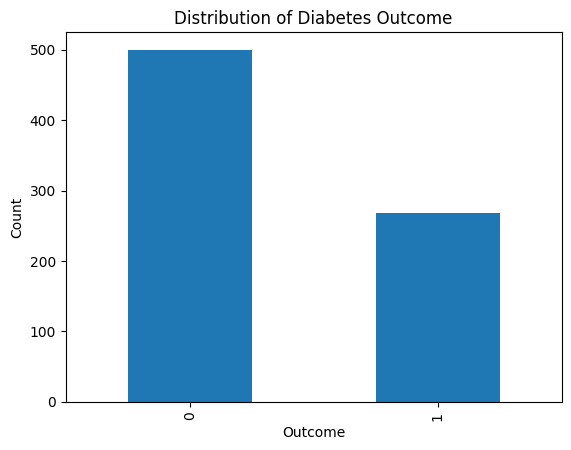

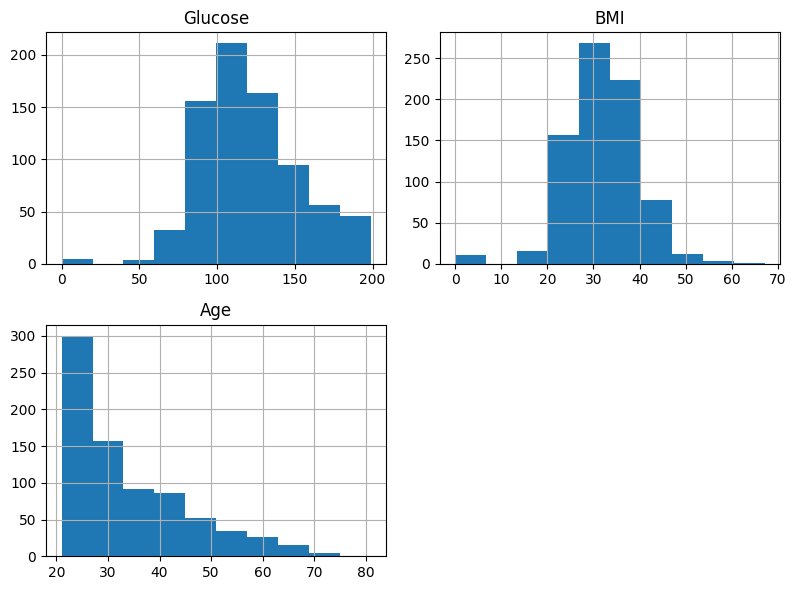

In [3]:
data['Outcome'].value_counts().plot(kind='bar')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Diabetes Outcome')
plt.show()
#A bar chart was used to visulaize the distribution of diabetes outcomes, providing an intuitive understanding of class imbalance.

#Feature Distribution
data[['Glucose','BMI','Age']].hist(figsize=(8,6))
plt.tight_layout()
plt.show()
#Histograms were plotted to observe the distribution of important clinical features such as glucose level, BMI, and age.

In [4]:
#Identifying invalid zero values.
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
(data[columns_with_zeros] ==0).sum()

#Certain medical measurements contain zero values that are not physiologically valid. These values were treated as missing data during preprocessing.

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [5]:
#Replace zeros with NaN
data[columns_with_zeros] = data[columns_with_zeros].replace(0,np.nan)

#Fill missing values using median.
data.fillna(data.median(), inplace=True)

#Median imputation was applied to replace missing values as it is robust to outliers and preserves the central tendency of medical data.


In [6]:
#Seperate features and target.
x = data.drop('Outcome', axis=1)
y = data['Outcome']
#Input features were seperated from the target variable to prepare the data for machine learning model training.

Feature Scaling

Feature standardization was not applied because Random Forest is a tree-based algorithm that does not rely on distance metrics or gradient optimization. Tree splits are based on threshold comparisons rather than feature magnitude, making scaling unnecessary.

And also noise was not explicitly removed from the dataset, as clinical variability represents real-world patient differences. Aggressive noise removal may lead to the exclusive of valid boarderline cases and reduce the model's ability to generalize to unseen data.

# Data Preprocessing Summary

Here what we did is, the dataset was analyzed to understand class distribution and feature characteristics. Invalid zero values were treated as missing data and replaced using median imputation.

In [7]:
#Data Splitting Strategy
#Train/Test Split
x_train_full, x_test, y_train_full, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify = y,
    random_state=42
)

Data Spliting Strategy

The dataset was divided into training and testing subsets using a 80-20 split. Stratified sampling was applied to preserve the original class distribution in both sets. The training set was used to learn model parameters,  while the test was reserved for final evaluation.

# Model Initialization

The random forest is imported from the scikit-learn library. This library provides an implementation of classical machine learning algorithms but does not supply pretrained models.

In [8]:
#Initializing Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth = 8,
    min_samples_split = 5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
    )
#The random forest model is initialized with specified hyperparameters.
#At this stage, the model contains no learned information and has not been exposed to any dataset.

# Pretrained Model Disclosure

The model used in this project is Random Forest, implemented using the scikit-learn library. This model does not come with pretrained weights and is not trained on any external dataset prior to this study. Therefore, no pretrained model was used.

# Weight Initialization Strategy

Random Forest does not use pretrained weights. Each decision tree starts with random sampling and learns solely from the provided dataset.

Random Initialization(training from scratch)

In [9]:
#We check model coefficients before training for transparency.
rf_model.coef_ if hasattr(rf_model,'coef_') else 'Model not trained yet'

#Since the model has not been trained, no coeffcients exist at this stage. This confirms that the model is initialized without pretrained weights.

'Model not trained yet'

So we could say no pretrained models or transfer learning techniques were used. All model parameters were learned from scratch during the training phase.

# Model Architecture

The random forest classifer is an ensemble machine learning model composed of multiple decision trees. Each tree is trained on a bootstrap sample of the dataset, and at each split, a random subset of features is considered. Final predictions are made using majority voting across all trees.

Random Forest was selected due tto its ability to model non-linear relationships, robustness to noise, and strong performance on tabular medical data. Compared to linear models, it demonstrated improved recall, which is critical for minimizing false negatives in diabetes screening tasks. Additinally, Random Foresr Does not require feature scaling and generalizes well on small datasets.

# Hyperparameter Explanation



*  n_estimators = 200 : Number of decision trees in the forest. A higher number improves stability and reduces variance.
*  max_depth = 8 : Limits the depth of each tree to prevent overfitting and improve generalization
*  min_samples_split = 5 : Minimum number of samples required to split an internal node, helping control tree complexity
*  min_samples_leaf = 2 : Minimum samples required at a leaf node, reducing noise-based splits
* class_weight = 'balanced' : Adjusts class weights automatically to handle class imbalance and improve recall for diabetic patients
* random_state = 42 : Ensures reproducibility by fixing randomness

These hyperparameters were selected to balance model complexity and generalization while prioritizing recall. Limiting tree depth and enforcing minimum samples per split prevents overfitting, while class balancing improves sensivity toward diabetic cases.





# Deep Learning-Specific Requirements

Layer freezing and Fine-Tuning

This model is a classical machine learning algothim and does not contain multiple layers, pretrained backbones, or fine-tuning mechanisms. Therefore, concepts such as frozen layers and partial training are not applicable.

# Weight Initialization

Random Forest does not use explicit numerical weights like linear or neural models. Instead, each decision tree is initialised using random bootstrap samples of the training data. Feature selection at each split is also randomized. This stochastic initialization ensures model diversity and reduces correlation between trees.

# Training Procedure

1.   Bootstrap sampling is applied to create multiple random subsets of the training data.
2.   For each subset, a decision tree is grown recursively.
3.  At each node, a random subset of features is evaluated.
4.  The best split is selected using impurity measures such as Gini index.
5.  Tree growth stops based on depth and minimum sample constraints.
6.  Final predictions are obtained by majority voting across all trees.



In [10]:
#k-fold training

kfold = StratifiedKFold(n_splits=5,
                        shuffle=True,
                        random_state=42
                        )
recall_scores = []
accuracy_scores = []

fold = 1
for train_idx, val_idx in kfold.split(x_train_full,y_train_full):
  print(f'Training fold {fold}')

  #Splitting data
  x_train, x_val = x_train_full.iloc[train_idx], x_train_full.iloc[val_idx]
  y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]



  #Model Training
  rf_model.fit(x_train, y_train) #Training Procedure explained above

  #Validation
  y_val_pred = rf_model.predict(x_val)

  recall = recall_score(y_val, y_val_pred)
  recall_scores.append(recall)

  accuracy = accuracy_score(y_val, y_val_pred)
  accuracy_scores.append(accuracy)

  print(f'Fold {fold} Recall: {recall_scores[-1]:.4f}  | Accuracy: {accuracy_scores[-1]:.4f}')
  fold += 1


Training fold 1
Fold 1 Recall: 0.6977  | Accuracy: 0.8130
Training fold 2
Fold 2 Recall: 0.7442  | Accuracy: 0.7805
Training fold 3
Fold 3 Recall: 0.6744  | Accuracy: 0.7967
Training fold 4
Fold 4 Recall: 0.6977  | Accuracy: 0.7561
Training fold 5
Fold 5 Recall: 0.6905  | Accuracy: 0.7869


In [11]:
#Mean k-fold performance
print('\nMean Recall:', np.mean(recall_scores))
print('Recall Standard Deviation:', np.std(recall_scores))


Mean Recall: 0.7008859357696566
Recall Standard Deviation: 0.023256868615013755


# Validation Strategy Justification

k-fold cross-validation was selected instead of a single train/validation/test split because the dataset is relatively small and class-imbalanced. k-fold validation ensures that every data point is used for both training and validation, resulting in a more reliable and stable estimate of model performance. This is particularly imporatant in medical prediction tasks where recall must be evaluated robustly.

In [12]:
#Final Model Training (Full Training Data)
rf_model.fit(x_train_full, y_train_full)  #Training Procedure explained above


RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, random_state=42)

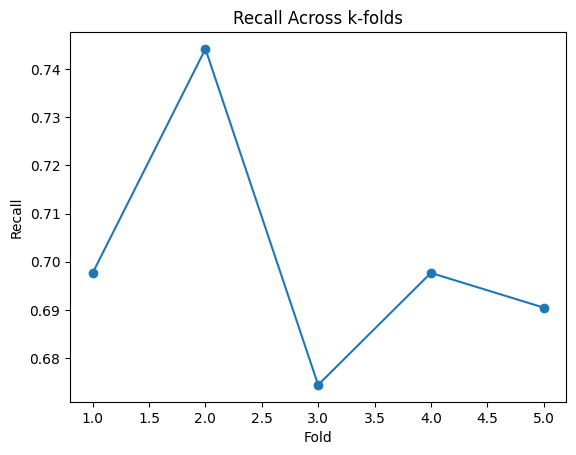

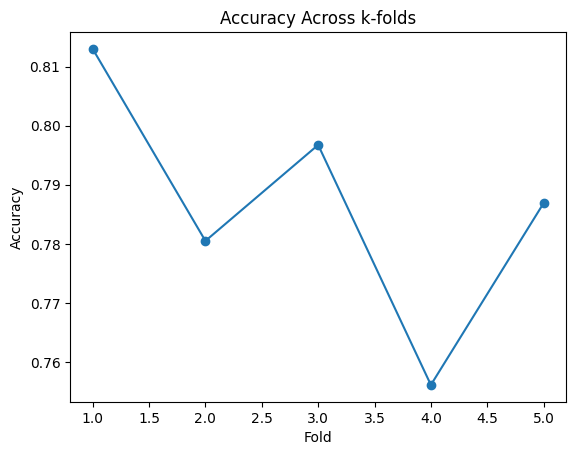

In [13]:
#Training Curves

#Recall
plt.plot(range(1,6), recall_scores, marker='o')
plt.xlabel('Fold')
plt.ylabel('Recall')
plt.title('Recall Across k-folds')
plt.show()
#Since false negatives are critical in diabetes, recall was tracked during training as a primary performance metric.
#The recall curve across k-fold illustrates performance stability across different data splits rather than learning progression over time.
#In medical classification, recall is prioritized over accuracy to minimize false negatives and ensure affected patients are correctly identified.


#Accuracy
plt.plot(range(1,6), accuracy_scores, marker='o')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across k-folds')
plt.show()

Loss Curves

Loss curves were not generated because Random Forest is a non-parametric ensemble model that does not optimize a continuous loss function using gradient descent. Instead, performance is evaluated using fold-wise validation metrics.

In [14]:
#Validation Metrics Summary
print('Mean Recall:', np.mean(recall_scores))
print('Recall Standard Deviation:', np.std(recall_scores))
print('Mean Accuracy:', np.mean(accuracy_scores))

#High recall consistency = reliable medical screening
#Low std deviation = stable model

Mean Recall: 0.7008859357696566
Recall Standard Deviation: 0.023256868615013755
Mean Accuracy: 0.7866453418632547


In [15]:
#Error Analysis


y_train_pred = rf_model.predict(x_train_full)

cm_train  = confusion_matrix(y_train_full, y_train_pred)
TN, FP,FN,TP = cm_train.ravel()

print('Confusion Matrix:')
print(cm_train)
print('True Positives:', TP)
print('False Positives:', FP)
print('True Negatives:', TN)
print('False Negatives:', FN)

#TP = Correctly predicted diabetic patients
#FP = Non-diabetic predicted as diabetic
#TN = Correctly predicted non-diabetic patients
#FN = Diabetic patients predicted as non-diabetic (dangerous)

Confusion Matrix:
[[368  32]
 [ 12 202]]
True Positives: 202
False Positives: 32
True Negatives: 368
False Negatives: 12


In [16]:
#Classification Report
print('Training Classification Report:')
print(classification_report(y_train_full, y_train_pred))

Training Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       400
           1       0.86      0.94      0.90       214

    accuracy                           0.93       614
   macro avg       0.92      0.93      0.92       614
weighted avg       0.93      0.93      0.93       614



In [17]:
#Identifying where errors happen

#Extract False negatives
false_negatives = x_train_full[(y_train_full == 1) & (y_train_pred == 0 )]

print("Number of False Negatives:", false_negatives.shape[0])
false_negatives.head()
#This shows actual diabetic patients that were missed.


Number of False Negatives: 12


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
709,2,93.0,64.0,32.0,160.0,38.0,0.674,23
619,0,119.0,72.0,29.0,125.0,32.4,0.141,24
321,3,112.0,74.0,30.0,125.0,31.6,0.197,25
197,3,107.0,62.0,13.0,48.0,22.9,0.678,23
284,2,108.0,80.0,29.0,125.0,27.0,0.259,52


Error analysis was conducted using the training confusion matrix to understand the types of errors made by the model. The most critical errors observed were false, negatives, where diabetic patients were classified as non-diabetic. These errors may arise due to overlapping feature distributions between diabetic and non-diabetic individuals, particularly for borderline glucose and BMI values. Although the model demonstrates reasonable recall, some subtle patterns remain difficult to distinguish using the available clinical features.

# Computational Constraints Faced

The model was trained on a CPU-based environment without GPU acceleration. Random Forest training time increased with the number of trees but remained under a few seconds due to moderate dataset size. Memory usage was minimal and suitable for deployment in low-resource environments.

In [18]:
#Performance Metrics (Test Data Only)

#Predictions
y_test_pred = rf_model.predict(x_test)
y_test_prob = rf_model.predict_proba(x_test)[:,1]

#Primary Meric : Recall
#In diabetes detection, false negatives are critical because undetected diabetic patients may not receive timely treatment.
#Therefore, recall(sensivity) is chosen as the primary metric.
test_recall = recall_score(y_test, y_test_pred)
print('Test Recall:', test_recall)
#Recall meassures the proportion of actual diabetic patients correctly identified by the model.
#A higher recall indicates fewer missed diabetic cases.



#Secondary Metrics
#Secondary metrics provide complementary insights into model performance.
test_accuracy = accuracy_score(y_test, y_test_pred)  #Overall Correctness
print('Test Accuracy:', test_accuracy)

test_precision = precision_score(y_test, y_test_pred) #Controls false positives
print('Test Precision:', test_precision)

test_f1 = f1_score(y_test, y_test_pred) #Balances precision and recall
print('Test F1 Score:', test_f1)

#Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm_test.ravel()

print('Confusion Matrix:')
print(cm_test)
print('True Positives:', TP)  #Correctly detected diabetic patients
print('False Positives:', FP)  #False alarms
print('True Negatives:', TN)   #Correctly detected non-diabetes
print('False Negatives:', FN)  #Missed diabetic cases (most critical)
#The confusion matrix highlights the presence of the false negatives, which are particularly crotical in medical doagnosis.
#Minimizing false negatives was prioritized during model development.

Test Recall: 0.6851851851851852
Test Accuracy: 0.7597402597402597
Test Precision: 0.6491228070175439
Test F1 Score: 0.6666666666666666
Confusion Matrix:
[[80 20]
 [17 37]]
True Positives: 37
False Positives: 20
True Negatives: 80
False Negatives: 17


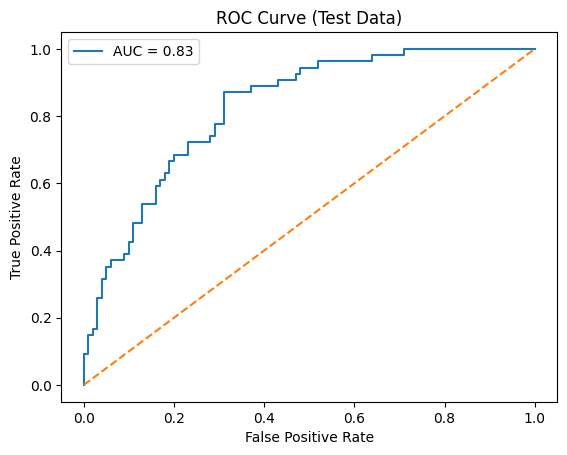

In [19]:
#ROC curve
#ROC curves evaluate performance independent of classification threshold.
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Data)")
plt.legend()
plt.show()

#ROC curve shows trade-off between sensivity and false positives
#AUC summarizes overall discriminative ability


# Reproducibility

To ensure reproducibility, random seeds were fixed for all stochastic components, including weight initialization and data splitting. All code ceels are organized sequentially and can be executed from top to bottom without manual intervention, producing consistent results across runs.